# STTC High-Activity Coactivity Network

Build lightweight weighted STTC functional coactivity networks from spike/MUA events restricted to **high-activity non-burst** periods. The analysis follows the Cutts-Eglen spike time tiling coefficient used in the Akarca/Dunn eLife functional-connectivity workflow, but intentionally avoids default all-pair surrogate inference.

Default output is a weighted adjacency matrix plus thresholded edge views for graph exploration.

In [49]:
%matplotlib inline
import hashlib
import json
import pickle
import sys
import time
from pathlib import Path
from types import SimpleNamespace

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from ephax import PrepConfig, RestingActivityDataset
from ephax.metrics import (
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    compute_sttc_adjacency,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
    normalize_interval_array,
    read_sttc_network_cache,
    spike_times_by_electrode_in_intervals,
    sttc_spike_proportion,
    sttc_tiling_proportion,
    thresholded_edge_table,
    write_sttc_network_cache,
)

In [65]:
# Dataset / scope. Keep names aligned with burst_analysis.ipynb and activity_distance_spike.ipynb.
DATASET = "stim_removal_null"  # "stim_removal_null" or "raw_h5"
# Scope booleans. These define the requested matrix directly:
#   False/False: one cell = WELL x DIV
#   True/False:  one DIV column = all AGGREGATE_WELLS x DIV
#   False/True:  one well row = WELL x all AGGREGATE_DIVS
#   True/True:   full matrix = all AGGREGATE_WELLS x all AGGREGATE_DIVS
RUN_ALL_WELLS = False
RUN_ALL_DIVS = True
WELL = 0
DIV = 21
DIVS = [12, 14, 21, 22, 23]
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
AGGREGATE_DIVS = DIVS

# Derived label for cache summaries and plot titles only. Compute logic uses RUN_ALL_WELLS/RUN_ALL_DIVS.
if RUN_ALL_WELLS and RUN_ALL_DIVS:
    RUN_MODE = "all_wells_all_divs"
elif RUN_ALL_WELLS:
    RUN_MODE = "all_wells_single_div"
elif RUN_ALL_DIVS:
    RUN_MODE = "single_well_all_divs"
else:
    RUN_MODE = "single_recording"

START_SEC = 0.0
END_SEC = 600.0
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000

# State detection, copied from the burst-analysis defaults.
IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0
NETWORK_MAX_GAP_BINS = 0

# STTC network settings.
STTC_DT_MS = 10.0
STTC_MIN_RATE_HZ = 0.01
STTC_MAX_ELECTRODES = 1000  # set None for all selected electrodes
STTC_KEEP_NEGATIVE = False
STTC_TOP_EDGE_FRACTIONS = [0.01, 0.05, 0.10]
STTC_ABS_THRESHOLD = None
STTC_NULL_REPS = 1
STTC_NULL_RESIDUAL_FORCE_RECOMPUTE = False
STTC_NULL_PAIR_SAMPLE_PER_RECORDING = 3000
STTC_NULL_PAIR_DISTANCE_BIN_UM = 200.0
STTC_NULL_PAIR_STRATIFY_BY_DISTANCE = True
STTC_DISTANCE_CURVE_BIN_UM = 100.0
STTC_DISTANCE_CURVE_MAX_UM = 3500.0
STTC_RANDOM_SEED = 0
STTC_FORCE_RECOMPUTE = False
STTC_STATE_FORCE_RECOMPUTE = False

STTC_ACTIVITY_SCOPE = "high_activity_non_burst" # "high_activity_non_burst" or "high_activity" or "burst"
OUTPUT_DIR = repo_root / "outputs" / "sttc_networks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STIM_DATA_ROOT = repo_root / "ephax" / "data" / "stimRemovalNull"
RAW_H5_DIV = 40
H5_FILE_INFO = [
    ("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/Stimulation/2407/ephaptic_stimulation_caspfiguration_control_2.raw.h5", well, div)
    for well in AGGREGATE_WELLS
    for div in [RAW_H5_DIV]
]

## Loading and State Helpers

The analysis state is defined as high-activity intervals after subtracting participation-defined bursts. Spike times are then restricted to these intervals and concatenated in interval-relative time, so removed gaps do not contribute to STTC tiled recording time.

In [51]:
def stim_recording_path(well: int, div: int) -> Path:
    # Match Figure 2 / burst_analysis: files live under stimRemovalNull/well{well}/...
    return STIM_DATA_ROOT / f"well{int(well)}" / f"DIV{int(div)}_240703_data_well{int(well)}_exp_data.npz"


def build_recording_spec(well: int, div: int) -> dict:
    if DATASET == "stim_removal_null":
        path = stim_recording_path(well, div)
        return {
            "dataset": DATASET,
            "well": int(well),
            "div": int(div),
            "recording_id": f"stimRemovalNull_well{int(well)}_DIV{int(div)}",
            "source_file": path,
            "source": "npz",
            "base_dir": None,
        }
    if DATASET == "raw_h5":
        # Processed H5 loader expects (folder, filename, start, end, well).
        if isinstance(H5_FILE_INFO, dict):
            if int(well) not in H5_FILE_INFO:
                raise ValueError(f"No raw_h5 file info configured for well {well}.")
            folder, filename, source_well = H5_FILE_INFO[int(well)]
            path = Path(folder) / filename
        else:
            matches = [item for item in H5_FILE_INFO if int(item[1]) == int(well)]
            if not matches:
                raise ValueError(f"No raw_h5 file info configured for well {well}.")
            raw_path, source_well, _ = matches[0]
            raw_path = Path(raw_path)
            folder, filename = str(raw_path.parent), raw_path.name
            path = raw_path
        return {
            "dataset": DATASET,
            "well": int(well),
            "div": int(RAW_H5_DIV),
            "recording_id": f"raw_h5_well{int(well)}_DIV{int(RAW_H5_DIV)}",
            "source_file": path,
            "source": "h5",
            "base_dir": None,
            "h5_folder": folder,
            "h5_filename": filename,
            "h5_well": int(source_well),
        }
    raise ValueError(f"Unsupported DATASET={DATASET!r}")


def requested_wells() -> list[int]:
    return [int(w) for w in (AGGREGATE_WELLS if RUN_ALL_WELLS else [WELL])]


def requested_divs() -> list[int]:
    return [int(d) for d in (AGGREGATE_DIVS if RUN_ALL_DIVS else [DIV])]


def iter_recording_specs() -> list[dict]:
    return [build_recording_spec(well, div) for div in requested_divs() for well in requested_wells()]


def rebase_dataset_clock(ds):
    # Figure 2 uses a zero-based analysis clock after loading the requested recording window.
    for rec in ds.recordings:
        offset_s = float(rec.start_time)
        rec.spikes = {**rec.spikes, "time": np.asarray(rec.spikes["time"], dtype=float) - offset_s}
        rec.end_time = float(rec.end_time) - offset_s
        rec.start_time = 0.0
    return ds


def load_recording_from_spec(spec: dict):
    start_sec = float(START_SEC)
    end_sec = float(END_SEC) if END_SEC is not None else None
    if spec["source"] == "npz":
        path = Path(spec["source_file"])
        if not path.exists():
            raise FileNotFoundError(f"Missing stimRemovalNull file: {path}")
        with np.load(path, allow_pickle=True) as data:
            sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
            frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
            rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0
        load_end = rec_t0 + end_sec if end_sec is not None else rec_t0 + 600.0
        file_info = [(str(path), rec_t0 + start_sec, load_end, int(spec["well"]))]
        ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=MIN_AMP)
    elif spec["source"] == "h5":
        load_end = end_sec if end_sec is not None else 600.0
        file_info = [(spec["h5_folder"], spec["h5_filename"], start_sec, load_end, int(spec["h5_well"]))]
        ds = RestingActivityDataset.from_file_info(file_info, source="h5", min_amp=MIN_AMP, base_dir=spec.get("base_dir"))
    else:
        raise ValueError(f"Unsupported source={spec['source']!r}")
    if not ds.recordings:
        raise ValueError(f"No recordings loaded for {spec['recording_id']}.")
    ds = rebase_dataset_clock(ds)
    return ds, ds.recordings[0]


def normalize_intervals_df(intervals) -> pd.DataFrame:
    arr = normalize_interval_array(intervals)
    if arr.size == 0:
        return pd.DataFrame(columns=["start_time_s", "end_time_s", "duration_s"])
    return pd.DataFrame({
        "start_time_s": arr[:, 0],
        "end_time_s": arr[:, 1],
        "duration_s": arr[:, 1] - arr[:, 0],
    })


def subtract_intervals(base, remove) -> pd.DataFrame:
    base_arr = normalize_interval_array(base)
    remove_arr = normalize_interval_array(remove)
    pieces = []
    for start, end in base_arr:
        current = [(float(start), float(end))]
        for r_start, r_end in remove_arr:
            next_current = []
            for c_start, c_end in current:
                if r_end <= c_start or r_start >= c_end:
                    next_current.append((c_start, c_end))
                    continue
                if r_start > c_start:
                    next_current.append((c_start, min(c_end, r_start)))
                if r_end < c_end:
                    next_current.append((max(c_start, r_end), c_end))
            current = next_current
            if not current:
                break
        pieces.extend(current)
    return normalize_intervals_df(pieces)


def coords_for_electrodes(recording, electrodes) -> np.ndarray:
    layout = pd.DataFrame(recording.layout)
    layout = layout.drop_duplicates("electrode").set_index("electrode")
    coords = layout.reindex(np.asarray(electrodes, dtype=int))[ ["x", "y"] ].to_numpy(dtype=float)
    return coords


In [52]:
ACTIVITY_STATE_CACHE_CONTENT = {
    "refs": "selected_electrodes_int32",
    "population": ["time_grid", "mean_ifr", "mean_ifr_smooth"],
    "interval_tables": ["high_epochs", "burst_epochs", "selected_intervals"],
}


def activity_state_cache_config(spec: dict) -> dict:
    return {
        "recording_id": spec["recording_id"],
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": int(spec["div"]),
        "start_sec": START_SEC,
        "end_sec": END_SEC,
        "min_amp": MIN_AMP,
        "top_start": TOP_START,
        "top_stop": TOP_STOP,
        "ifr_grid_hz": IFR_GRID_HZ,
        "smooth_sigma_sec": SMOOTH_SIGMA_SEC,
        "high_activity_mad_scale": HIGH_ACTIVITY_MAD_SCALE,
        "high_activity_min_duration_ms": HIGH_ACTIVITY_MIN_DURATION_MS,
        "high_activity_max_gap_bins": HIGH_ACTIVITY_MAX_GAP_BINS,
        "highres_bin_ms": HIGHRES_BIN_MS,
        "highres_smooth_sigma_ms": HIGHRES_SMOOTH_SIGMA_MS,
        "network_bin_ms": NETWORK_BIN_MS,
        "network_min_participation_fraction": NETWORK_MIN_PARTICIPATION_FRACTION,
        "network_min_duration_ms": NETWORK_MIN_DURATION_MS,
        "network_max_gap_bins": NETWORK_MAX_GAP_BINS,
        "cache_content": ACTIVITY_STATE_CACHE_CONTENT,
    }


def activity_state_cache_path(spec: dict) -> Path:
    config = activity_state_cache_config(spec)
    digest = hashlib.sha1(json.dumps(config, sort_keys=True).encode("utf-8")).hexdigest()[:12]
    return OUTPUT_DIR / f"activity_state_{spec['recording_id']}_{digest}.pkl"


def compact_population_ifr(population) -> dict:
    return {
        "time_grid": np.asarray(population.time_grid, dtype=np.float32),
        "mean_ifr": np.asarray(population.mean_ifr, dtype=np.float32),
        "mean_ifr_smooth": np.asarray(population.mean_ifr_smooth, dtype=np.float32),
    }


def restore_population_ifr(population):
    if not isinstance(population, dict):
        return population
    required = {"time_grid", "mean_ifr", "mean_ifr_smooth"}
    missing = required.difference(population)
    if missing:
        raise ValueError(f"Activity-state cache population is missing fields: {sorted(missing)}")
    return SimpleNamespace(
        time_grid=np.asarray(population["time_grid"], dtype=float),
        mean_ifr=np.asarray(population["mean_ifr"], dtype=float),
        mean_ifr_smooth=np.asarray(population["mean_ifr_smooth"], dtype=float),
    )


def load_activity_state_cache(spec: dict):
    path = activity_state_cache_path(spec)
    if not path.exists() or STTC_STATE_FORCE_RECOMPUTE:
        return None
    with path.open("rb") as f:
        cached = pickle.load(f)
    if cached.get("cache_config") != activity_state_cache_config(spec):
        return None
    cached["population"] = restore_population_ifr(cached.get("population"))
    cached["summary"] = {**cached["summary"], "state_cache_source": "cache", "state_cache_path": str(path)}
    return cached


def write_activity_state_cache(spec: dict, payload: dict):
    path = activity_state_cache_path(spec)
    cache_payload = {
        "cache_config": activity_state_cache_config(spec),
        "refs": np.asarray(payload["refs"], dtype=np.int32),
        "population": compact_population_ifr(payload["population"]),
        "high_epochs": payload["high_epochs"],
        "burst_epochs": payload["burst_epochs"],
        "selected_intervals": payload["selected_intervals"],
        "summary": {**payload["summary"], "state_cache_source": "computed", "state_cache_path": str(path)},
    }
    with path.open("wb") as f:
        pickle.dump(cache_payload, f, protocol=pickle.HIGHEST_PROTOCOL)

def detect_recording_activity(spec: dict) -> dict:
    t0 = time.perf_counter()
    try:
        ds, rec = load_recording_from_spec(spec)
        cached = load_activity_state_cache(spec)
        if cached is not None:
            summary = {
                **cached["summary"],
                "start_sec": float(rec.start_time),
                "end_sec": float(rec.end_time),
                "n_spikes": int(len(rec.spikes["time"])),
                "n_active_electrodes": int(np.unique(rec.spikes["electrode"]).size),
                "elapsed_s": time.perf_counter() - t0,
            }
            return {
                "spec": spec,
                "dataset_obj": ds,
                "recording": rec,
                "refs": np.asarray(cached["refs"], dtype=int),
                "population": cached["population"],
                "high_epochs": cached["high_epochs"],
                "burst_epochs": cached["burst_epochs"],
                "selected_intervals": cached["selected_intervals"],
                "summary": summary,
            }

        prep_cfg = PrepConfig(
            min_amp=MIN_AMP,
            mode="top",
            top_start=TOP_START,
            top_stop=TOP_STOP,
            top_use_recording_window=True,
            verbose=False,
        )
        refs = ds.select_ref_electrodes(prep_cfg)[0]
        if refs.size == 0:
            raise ValueError("No reference electrodes selected.")

        population = build_population_ifr(
            rec,
            refs,
            grid_hz=IFR_GRID_HZ,
            smooth_sigma_sec=SMOOTH_SIGMA_SEC,
        )
        high_epochs, high_info = detect_high_activity_epochs(
            population.time_grid,
            population.mean_ifr_smooth,
            mad_scale=HIGH_ACTIVITY_MAD_SCALE,
            min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
            max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
        )
        highres = build_highres_traces(
            rec,
            refs,
            bin_ms=HIGHRES_BIN_MS,
            smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
        )
        activity = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
        burst_epochs = detect_participation_burst_epochs(
            activity,
            high_epochs,
            min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
            min_duration_ms=NETWORK_MIN_DURATION_MS,
            max_gap_bins=NETWORK_MAX_GAP_BINS,
        )
        selected_intervals = subtract_intervals(high_epochs, burst_epochs)
        selected_intervals = selected_intervals[selected_intervals["duration_s"] > 0].reset_index(drop=True)
        selected_intervals["event_idx"] = np.arange(len(selected_intervals), dtype=int)

        summary = {
            **{k: spec[k] for k in ["dataset", "well", "div", "recording_id", "source_file"]},
            "valid_for_sttc": len(selected_intervals) > 0,
            "skip_reason": "" if len(selected_intervals) > 0 else "no_high_activity_non_burst_intervals",
            "start_sec": float(rec.start_time),
            "end_sec": float(rec.end_time),
            "n_spikes": int(len(rec.spikes["time"])),
            "n_active_electrodes": int(np.unique(rec.spikes["electrode"]).size),
            "n_refs": int(refs.size),
            "n_high_activity_periods": int(len(high_epochs)),
            "n_burst_periods": int(len(burst_epochs)),
            "n_selected_periods": int(len(selected_intervals)),
            "selected_duration_s": float(selected_intervals["duration_s"].sum()) if len(selected_intervals) else 0.0,
            "high_activity_threshold_hz": float(high_info.get("threshold_hz", np.nan)),
            "state_cache_source": "computed",
            "state_cache_path": str(activity_state_cache_path(spec)),
            "elapsed_s": time.perf_counter() - t0,
        }
        payload = {
            "spec": spec,
            "dataset_obj": ds,
            "recording": rec,
            "refs": refs,
            "population": population,
            "high_epochs": high_epochs,
            "burst_epochs": burst_epochs,
            "selected_intervals": selected_intervals,
            "summary": summary,
        }
        write_activity_state_cache(spec, payload)
        return payload
    except Exception as exc:
        return {
            "spec": spec,
            "dataset_obj": None,
            "recording": None,
            "refs": np.array([], dtype=int),
            "population": None,
            "high_epochs": pd.DataFrame(),
            "burst_epochs": pd.DataFrame(),
            "selected_intervals": pd.DataFrame(),
            "summary": {
                **{k: spec[k] for k in ["dataset", "well", "div", "recording_id", "source_file"]},
                "valid_for_sttc": False,
                "skip_reason": str(exc),
                "start_sec": np.nan,
                "end_sec": np.nan,
                "n_spikes": 0,
                "n_active_electrodes": 0,
                "n_refs": 0,
                "n_high_activity_periods": 0,
                "n_burst_periods": 0,
                "n_selected_periods": 0,
                "selected_duration_s": 0.0,
                "high_activity_threshold_hz": np.nan,
                "elapsed_s": time.perf_counter() - t0,
            },
        }


recording_specs = iter_recording_specs()
activity_results = [detect_recording_activity(spec) for spec in recording_specs]
recording_summary = pd.DataFrame([item["summary"] for item in activity_results])
recording_summary

,dataset,well,div,recording_id,source_file,valid_for_sttc,skip_reason,start_sec,end_sec,n_spikes,n_active_electrodes,n_refs,n_high_activity_periods,n_burst_periods,n_selected_periods,selected_duration_s,high_activity_threshold_hz,state_cache_source,state_cache_path,elapsed_s
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,252494,1005,1000,27,141,168,131.24,0.182375,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.340462
1,stim_removal_null,0,14,stimRemovalNull_well0_DIV14,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,263329,1011,1000,26,122,148,149.65,0.214701,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.206820
2,stim_removal_null,0,21,stimRemovalNull_well0_DIV21,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,98520,988,988,90,69,159,74.83,0.183497,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.079444
3,stim_removal_null,0,22,stimRemovalNull_well0_DIV22,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,63828,218,218,90,114,204,66.35,0.559884,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.082609
4,stim_removal_null,0,23,stimRemovalNull_well0_DIV23,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,108277,634,634,106,85,191,62.47,0.452775,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.096759


In [53]:
interval_rows = []
for item in activity_results:
    for kind, table in [
        ("high_activity", item["high_epochs"]),
        ("burst", item["burst_epochs"]),
        ("high_activity_non_burst", item["selected_intervals"]),
    ]:
        if table is None or len(table) == 0:
            continue
        for row in table.itertuples(index=False):
            start = float(getattr(row, "start_time_s"))
            end = float(getattr(row, "end_time_s"))
            interval_rows.append({
                "dataset": item["spec"]["dataset"],
                "well": item["spec"]["well"],
                "div": item["spec"]["div"],
                "recording_id": item["spec"]["recording_id"],
                "interval_kind": kind,
                "start_time_s": start,
                "end_time_s": end,
                "duration_s": end - start,
            })
interval_summary = pd.DataFrame(interval_rows)
interval_summary.head()

,dataset,well,div,recording_id,interval_kind,start_time_s,end_time_s,duration_s
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,15.88,21.78,5.90
1,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,40.04,45.14,5.10
2,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,61.56,66.62,5.06
3,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,81.36,87.36,6.00
4,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,104.26,109.40,5.14


## State QC

The selected intervals are the orange spans: high-activity periods with participation-burst epochs removed.

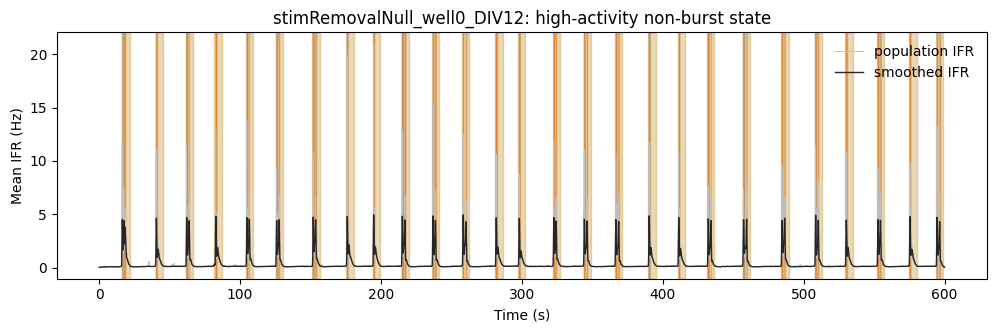

In [54]:
def draw_state_qc(item):
    if item["population"] is None:
        raise ValueError("No population IFR available for this recording.")
    pop = item["population"]
    fig, ax = plt.subplots(figsize=(12, 3.2))
    ax.plot(pop.time_grid, pop.mean_ifr, color="0.75", lw=0.7, label="population IFR")
    ax.plot(pop.time_grid, pop.mean_ifr_smooth, color="0.15", lw=1.0, label="smoothed IFR")
    for row in item["high_epochs"].itertuples(index=False):
        ax.axvspan(float(row.start_time_s), float(row.end_time_s), color="tab:green", alpha=0.12)
    for row in item["burst_epochs"].itertuples(index=False):
        ax.axvspan(float(row.start_time_s), float(row.end_time_s), color="tab:blue", alpha=0.16)
    for row in item["selected_intervals"].itertuples(index=False):
        ax.axvspan(float(row.start_time_s), float(row.end_time_s), color="tab:orange", alpha=0.22)
    ax.set_title(f"{item['spec']['recording_id']}: high-activity non-burst state")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Mean IFR (Hz)")
    ax.legend(loc="upper right", frameon=False)
    return fig, ax

valid_activity_items = [item for item in activity_results if item["summary"]["valid_for_sttc"]]
if valid_activity_items:
    draw_state_qc(valid_activity_items[0]);
else:
    print("No valid high-activity non-burst intervals were found.")

## Compute or Load STTC Networks

The STTC matrix is cached per recording. Re-running plotting cells will not recompute the pairwise matrix unless `STTC_FORCE_RECOMPUTE=True` or the cache path changes through configuration.

In [55]:
def config_digest_for_item(item, electrodes) -> str:
    payload = {
        "dataset": item["spec"]["dataset"],
        "recording_id": item["spec"]["recording_id"],
        "start_sec": item["summary"].get("start_sec"),
        "end_sec": item["summary"].get("end_sec"),
        "activity_scope": STTC_ACTIVITY_SCOPE,
        "dt_ms": STTC_DT_MS,
        "min_rate_hz": STTC_MIN_RATE_HZ,
        "max_electrodes": STTC_MAX_ELECTRODES,
        "keep_negative": STTC_KEEP_NEGATIVE,
        "top_start": TOP_START,
        "top_stop": TOP_STOP,
        "electrodes": list(map(int, np.asarray(electrodes, dtype=int))),
        "intervals": np.round(item["selected_intervals"][["start_time_s", "end_time_s"]].to_numpy(dtype=float), 6).tolist(),
    }
    return hashlib.sha1(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:12]


def sttc_cache_path(item, digest: str) -> Path:
    spec = item["spec"]
    max_label = "all" if STTC_MAX_ELECTRODES is None else str(int(STTC_MAX_ELECTRODES))
    dt_label = f"{float(STTC_DT_MS):g}".replace(".", "p")
    return OUTPUT_DIR / f"sttc_{spec['recording_id']}_{STTC_ACTIVITY_SCOPE}_dt{dt_label}ms_max{max_label}_{digest}.h5"


def select_sttc_electrodes(item) -> np.ndarray:
    refs = np.asarray(item["refs"], dtype=int)
    if STTC_MAX_ELECTRODES is None or refs.size <= int(STTC_MAX_ELECTRODES):
        return refs
    # Refs from PrepConfig(mode='top') are already activity sorted. Keep the most active cap deterministically.
    return refs[: int(STTC_MAX_ELECTRODES)]


def compute_or_load_sttc_network(item):
    if not item["summary"]["valid_for_sttc"]:
        return None
    rec = item["recording"]
    electrodes_requested = select_sttc_electrodes(item)
    digest = config_digest_for_item(item, electrodes_requested)
    path = sttc_cache_path(item, digest)
    if path.exists() and not STTC_FORCE_RECOMPUTE:
        cached = read_sttc_network_cache(path)
        adjacency = cached["adjacency"]
        electrodes = cached["electrodes"].astype(int)
        coords_um = cached["coords_um"]
        rates_hz = cached["rates_hz"]
        intervals = cached["intervals_s"]
        source = "cache"
    else:
        t0 = time.perf_counter()
        intervals = item["selected_intervals"][["start_time_s", "end_time_s"]].to_numpy(dtype=float)
        spikes_by_electrode, retained_duration_s = spike_times_by_electrode_in_intervals(rec, electrodes_requested, intervals)
        result = compute_sttc_adjacency(
            spikes_by_electrode,
            retained_duration_s,
            dt_ms=STTC_DT_MS,
            min_rate_hz=STTC_MIN_RATE_HZ,
            keep_negative=STTC_KEEP_NEGATIVE,
        )
        electrodes = result["electrodes"].astype(int)
        adjacency = result["adjacency"]
        rates_hz = result["rates_hz"]
        coords_um = coords_for_electrodes(rec, electrodes)
        config = {
            "dataset": item["spec"]["dataset"],
            "recording_id": item["spec"]["recording_id"],
            "well": int(item["spec"]["well"]),
            "div": int(item["spec"]["div"]),
            "activity_scope": STTC_ACTIVITY_SCOPE,
            "dt_ms": float(STTC_DT_MS),
            "min_rate_hz": float(STTC_MIN_RATE_HZ),
            "max_electrodes": -1 if STTC_MAX_ELECTRODES is None else int(STTC_MAX_ELECTRODES),
            "keep_negative": int(bool(STTC_KEEP_NEGATIVE)),
            "top_start": int(TOP_START),
            "top_stop": -1 if TOP_STOP is None else int(TOP_STOP),
            "retained_duration_s": float(retained_duration_s),
            "config_digest": digest,
            "compute_elapsed_s": float(time.perf_counter() - t0),
        }
        write_sttc_network_cache(
            path,
            adjacency=adjacency,
            electrodes=electrodes,
            coords_um=coords_um,
            rates_hz=rates_hz,
            intervals=intervals,
            config=config,
        )
        source = "computed"

    edge_tables = {}
    for fraction in STTC_TOP_EDGE_FRACTIONS:
        edge_tables[float(fraction)] = thresholded_edge_table(
            adjacency,
            electrodes,
            coords=coords_um,
            top_fraction=float(fraction),
        )
    return {
        "item": item,
        "cache_path": path,
        "source": source,
        "adjacency": adjacency,
        "electrodes": electrodes,
        "coords_um": coords_um,
        "rates_hz": rates_hz,
        "intervals_s": intervals,
        "edge_tables": edge_tables,
    }


def summarize_sttc_result(result) -> dict:
    adj = np.asarray(result["adjacency"], dtype=float)
    triu = adj[np.triu_indices_from(adj, k=1)] if adj.size else np.array([], dtype=float)
    positive = triu[np.isfinite(triu) & (triu > 0)]
    strength = np.nansum(np.maximum(adj, 0), axis=1) if adj.size else np.array([], dtype=float)
    spec = result["item"]["spec"]
    total_edges = adj.shape[0] * (adj.shape[0] - 1) / 2
    thresholds = {}
    for fraction in STTC_TOP_EDGE_FRACTIONS:
        if positive.size:
            thresholds[f"top_{int(100 * fraction)}pct_threshold"] = float(np.quantile(positive, max(0.0, 1.0 - float(fraction))))
        else:
            thresholds[f"top_{int(100 * fraction)}pct_threshold"] = np.nan
    return {
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": int(spec["div"]),
        "recording_id": spec["recording_id"],
        "cache_source": result["source"],
        "cache_path": str(result["cache_path"]),
        "retained_interval_s": float(np.sum(np.asarray(result["intervals_s"])[:, 1] - np.asarray(result["intervals_s"])[:, 0])),
        "n_intervals": int(len(result["intervals_s"])),
        "n_electrodes": int(adj.shape[0]),
        "n_positive_edges": int(positive.size),
        "positive_edge_density": float(positive.size / total_edges) if total_edges else np.nan,
        "mean_positive_sttc": float(np.mean(positive)) if positive.size else np.nan,
        "median_positive_sttc": float(np.median(positive)) if positive.size else np.nan,
        "mean_node_strength": float(np.mean(strength)) if strength.size else np.nan,
        "median_node_strength": float(np.median(strength)) if strength.size else np.nan,
        **thresholds,
    }


sttc_results = [result for result in (compute_or_load_sttc_network(item) for item in activity_results) if result is not None]
sttc_summary_df = pd.DataFrame([summarize_sttc_result(result) for result in sttc_results])
sttc_summary_df.to_csv(OUTPUT_DIR / "sttc_recording_summary.csv", index=False)
sttc_summary_df

,dataset,well,div,recording_id,cache_source,cache_path,retained_interval_s,n_intervals,n_electrodes,n_positive_edges,positive_edge_density,mean_positive_sttc,median_positive_sttc,mean_node_strength,median_node_strength,top_1pct_threshold,top_5pct_threshold,top_10pct_threshold
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,131.24,168,924,226623,0.531447,0.074789,0.048300,36.685996,35.331610,0.373269,0.239969,0.176468
1,stim_removal_null,0,14,stimRemovalNull_well0_DIV14,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,149.65,148,944,232423,0.522186,0.077025,0.054862,37.928532,31.390884,0.326605,0.226564,0.174147
2,stim_removal_null,0,21,stimRemovalNull_well0_DIV21,computed,/Users/danielrebbin/Documents/GitHub/ephax/out...,74.83,159,959,390355,0.849778,0.360964,0.362508,293.856720,310.503221,0.732706,0.623917,0.571016
3,stim_removal_null,0,22,stimRemovalNull_well0_DIV22,computed,/Users/danielrebbin/Documents/GitHub/ephax/out...,66.35,204,218,23332,0.986429,0.420467,0.421876,90.003001,88.393043,0.808667,0.686891,0.620376
4,stim_removal_null,0,23,stimRemovalNull_well0_DIV23,computed,/Users/danielrebbin/Documents/GitHub/ephax/out...,62.47,191,632,187207,0.938870,0.365464,0.371398,216.510660,224.486260,0.732654,0.622661,0.568494


## Example Network Panels

These panels are descriptive views of the weighted STTC adjacency. Thresholds are visualization thresholds, not pairwise statistical significance tests.

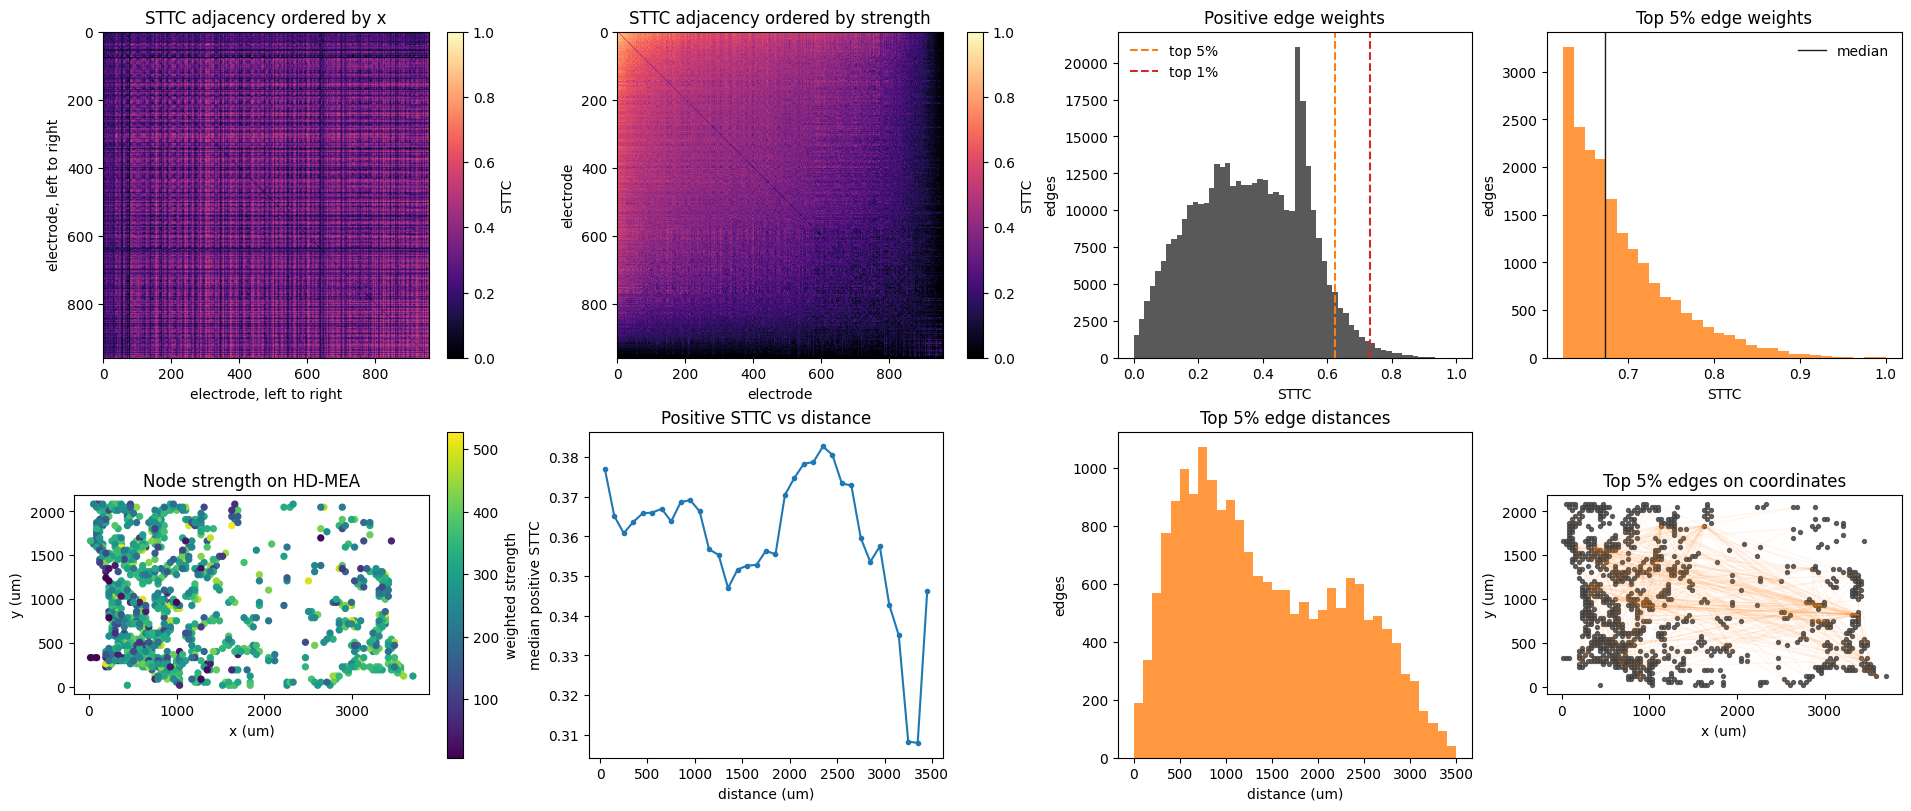

In [66]:
def find_sttc_result(well=None, div=None, fallback_first=True):
    if not sttc_results:
        raise ValueError("No STTC results are available.")
    candidates = sttc_results
    if well is not None:
        candidates = [r for r in candidates if int(r["item"]["spec"]["well"]) == int(well)]
    if div is not None:
        candidates = [r for r in candidates if int(r["item"]["spec"]["div"]) == int(div)]
    if candidates:
        return candidates[0]
    if fallback_first:
        print(f"No STTC result found for well={well}, div={div}; using first computed result instead.")
        return sttc_results[0]
    raise ValueError(f"No STTC result found for well={well}, div={div}.")


def get_example_sttc_result():
    # Flexible default: use the configured WELL/DIV when available, otherwise first computed result.
    # In single_div_all_wells this gives WELL at the selected DIV; in div_progression it gives WELL/DIV.
    return find_sttc_result(well=WELL, div=DIV, fallback_first=True)

def pair_distance_weight_table(result, adjacency=None) -> pd.DataFrame:
    adj = np.asarray(result["adjacency"] if adjacency is None else adjacency, dtype=float)
    coords = np.asarray(result["coords_um"], dtype=float)
    electrodes = np.asarray(result["electrodes"], dtype=int)
    i, j = np.triu_indices(adj.shape[0], k=1)
    weights = adj[i, j]
    delta = coords[i] - coords[j]
    distance_um = np.sqrt(np.sum(delta * delta, axis=1))
    return pd.DataFrame({
        "source_electrode": electrodes[i],
        "target_electrode": electrodes[j],
        "distance_um": distance_um,
        "sttc": weights,
    })


def binned_sttc_by_distance(result, bin_um=100, max_um=3500, adjacency=None) -> pd.DataFrame:
    pairs = pair_distance_weight_table(result, adjacency=adjacency)
    bins = np.arange(0, max_um + bin_um, bin_um, dtype=float)
    pairs = pairs[(pairs["distance_um"] >= bins[0]) & (pairs["distance_um"] < bins[-1])]
    pairs["distance_bin_um"] = pd.cut(pairs["distance_um"], bins=bins, labels=0.5 * (bins[:-1] + bins[1:]))
    rows = []
    for center, group in pairs.groupby("distance_bin_um", observed=True):
        values = group["sttc"].to_numpy(dtype=float)
        positive = values[values > 0]
        rows.append({
            "distance_um": float(center),
            "n_pairs": int(len(group)),
            "median_sttc": float(np.nanmedian(values)) if values.size else np.nan,
            "mean_sttc": float(np.nanmean(values)) if values.size else np.nan,
            "median_positive_sttc": float(np.nanmedian(positive)) if positive.size else np.nan,
            "positive_fraction": float(np.mean(values > 0)) if values.size else np.nan,
        })
    return pd.DataFrame(rows)


def edge_table_from_adjacency(result, adjacency, top_fraction=0.01):
    return thresholded_edge_table(
        adjacency,
        result["electrodes"],
        coords=result["coords_um"],
        top_fraction=float(top_fraction),
    )


def draw_example_network(result, adjacency=None, title_prefix=""):
    adj = np.asarray(result["adjacency"] if adjacency is None else adjacency, dtype=float)
    coords = np.asarray(result["coords_um"], dtype=float)
    strength = np.nansum(np.maximum(adj, 0), axis=1)
    weights = adj[np.triu_indices_from(adj, k=1)]
    positive = weights[np.isfinite(weights) & (weights > 0)]
    top1_threshold = np.quantile(positive, 0.99) if positive.size else np.nan
    top5_threshold = np.quantile(positive, 0.95) if positive.size else np.nan

    # X-only ordering makes left-right spatial structure visible as diagonal bands.
    order_x = np.argsort(coords[:, 0], kind="mergesort")
    order_strength = np.argsort(strength)[::-1]
    distance_summary = binned_sttc_by_distance(result, adjacency=adj)
    pair_table = pair_distance_weight_table(result, adjacency=adj)
    top5_pairs = pair_table[pair_table["sttc"] >= top5_threshold].copy() if np.isfinite(top5_threshold) else pd.DataFrame()
    top1_pairs = pair_table[pair_table["sttc"] >= top1_threshold].copy() if np.isfinite(top1_threshold) else pd.DataFrame()

    fig, axes = plt.subplots(2, 4, figsize=(19, 8), constrained_layout=True)
    im0 = axes[0, 0].imshow(adj[np.ix_(order_x, order_x)], cmap="magma", vmin=0)
    axes[0, 0].set_title(f"{title_prefix}STTC adjacency ordered by x")
    axes[0, 0].set_xlabel("electrode, left to right")
    axes[0, 0].set_ylabel("electrode, left to right")
    fig.colorbar(im0, ax=axes[0, 0], label="STTC")

    im1 = axes[0, 1].imshow(adj[np.ix_(order_strength, order_strength)], cmap="magma", vmin=0)
    axes[0, 1].set_title(f"{title_prefix}STTC adjacency ordered by strength")
    axes[0, 1].set_xlabel("electrode")
    axes[0, 1].set_ylabel("electrode")
    fig.colorbar(im1, ax=axes[0, 1], label="STTC")

    axes[0, 2].hist(positive, bins=60, color="0.35")
    if np.isfinite(top5_threshold):
        axes[0, 2].axvline(top5_threshold, color="tab:orange", ls="--", label="top 5%")
    if np.isfinite(top1_threshold):
        axes[0, 2].axvline(top1_threshold, color="tab:red", ls="--", label="top 1%")
    axes[0, 2].set_title(f"{title_prefix}Positive edge weights")
    axes[0, 2].set_xlabel("STTC")
    axes[0, 2].set_ylabel("edges")
    axes[0, 2].legend(frameon=False)

    if not top5_pairs.empty:
        axes[0, 3].hist(top5_pairs["sttc"], bins=30, color="tab:orange", alpha=0.8)
        axes[0, 3].axvline(float(np.median(top5_pairs["sttc"])), color="0.1", lw=1.0, label="median")
    axes[0, 3].set_title(f"{title_prefix}Top 5% edge weights")
    axes[0, 3].set_xlabel("STTC")
    axes[0, 3].set_ylabel("edges")
    axes[0, 3].legend(frameon=False)

    sc = axes[1, 0].scatter(coords[:, 0], coords[:, 1], c=strength, s=18, cmap="viridis")
    axes[1, 0].set_title(f"{title_prefix}Node strength on HD-MEA")
    axes[1, 0].set_xlabel("x (um)")
    axes[1, 0].set_ylabel("y (um)")
    axes[1, 0].set_aspect("equal", adjustable="box")
    fig.colorbar(sc, ax=axes[1, 0], label="weighted strength")

    axes[1, 1].plot(distance_summary["distance_um"], distance_summary["median_positive_sttc"], marker="o", ms=3)
    axes[1, 1].set_title(f"{title_prefix}Positive STTC vs distance")
    axes[1, 1].set_xlabel("distance (um)")
    axes[1, 1].set_ylabel("median positive STTC")

    if not top5_pairs.empty:
        axes[1, 2].hist(top5_pairs["distance_um"], bins=np.arange(0, 3600, 100), color="tab:orange", alpha=0.8)
    axes[1, 2].set_title(f"{title_prefix}Top 5% edge distances")
    axes[1, 2].set_xlabel("distance (um)")
    axes[1, 2].set_ylabel("edges")

    top_edges = edge_table_from_adjacency(result, adj, top_fraction=0.01)
    axes[1, 3].scatter(coords[:, 0], coords[:, 1], s=8, color="0.25", alpha=0.8)
    if top_edges is not None and len(top_edges):
        by_electrode = {int(e): idx for idx, e in enumerate(result["electrodes"])}
        for row in top_edges.head(400).itertuples(index=False):
            a = by_electrode[int(row.source_electrode)]
            b = by_electrode[int(row.target_electrode)]
            axes[1, 3].plot([coords[a, 0], coords[b, 0]], [coords[a, 1], coords[b, 1]], color="tab:orange", alpha=0.08, lw=0.8)
    axes[1, 3].set_title(f"{title_prefix}Top 5% edges on coordinates")
    axes[1, 3].set_xlabel("x (um)")
    axes[1, 3].set_ylabel("y (um)")
    axes[1, 3].set_aspect("equal", adjustable="box")
    return fig, axes

if sttc_results:
    example_sttc_result = get_example_sttc_result()
    draw_example_network(example_sttc_result);
else:
    example_sttc_result = None
    print("No STTC network was available to plot.")


## Lightweight Null Diagnostic (Optional)

Disabled by default. When enabled, this applies independent circular shifts to each electrode's interval-concatenated spike train and reports a global null edge-weight distribution. It is a sanity diagnostic, not pairwise significance inference.

In [57]:
def circular_shift_spikes(spikes_by_electrode, duration_s, rng):
    shifted = {}
    for electrode, times in spikes_by_electrode.items():
        times = np.asarray(times, dtype=float)
        if times.size == 0 or duration_s <= 0:
            shifted[int(electrode)] = times.copy()
            continue
        shift = rng.uniform(0.0, duration_s)
        shifted[int(electrode)] = np.sort((times + shift) % duration_s)
    return shifted


def run_light_null_for_result(result, n_reps=STTC_NULL_REPS, adjacency_reps=STTC_NULL_REPS):
    if n_reps <= 0:
        return pd.DataFrame(), None
    item = result["item"]
    intervals = item["selected_intervals"][["start_time_s", "end_time_s"]].to_numpy(dtype=float)
    spikes_by_electrode, duration_s = spike_times_by_electrode_in_intervals(item["recording"], result["electrodes"], intervals)
    rng = np.random.default_rng(STTC_RANDOM_SEED)
    rows = []
    null_sum = None
    n_for_adjacency = 0
    for rep in range(int(n_reps)):
        shifted = circular_shift_spikes(spikes_by_electrode, duration_s, rng)
        null = compute_sttc_adjacency(
            shifted,
            duration_s,
            dt_ms=STTC_DT_MS,
            min_rate_hz=STTC_MIN_RATE_HZ,
            keep_negative=STTC_KEEP_NEGATIVE,
        )["adjacency"]
        weights = null[np.triu_indices_from(null, k=1)]
        positive = weights[weights > 0]
        rows.append({
            "rep": rep,
            "mean_positive_sttc": float(np.mean(positive)) if positive.size else np.nan,
            "median_positive_sttc": float(np.median(positive)) if positive.size else np.nan,
            "p95_positive_sttc": float(np.quantile(positive, 0.95)) if positive.size else np.nan,
            "positive_fraction": float(np.mean(weights > 0)) if weights.size else np.nan,
        })
        if rep < int(adjacency_reps):
            null_sum = null.astype(np.float64, copy=True) if null_sum is None else null_sum + null
            n_for_adjacency += 1
    null_mean = (null_sum / max(1, n_for_adjacency)).astype(np.float32) if n_for_adjacency else None
    return pd.DataFrame(rows), null_mean

if STTC_NULL_REPS > 0 and sttc_results:
    example_sttc_result = get_example_sttc_result()
    light_null_df, light_null_mean_adjacency = run_light_null_for_result(example_sttc_result)
    light_null_df
else:
    light_null_df = pd.DataFrame()
    light_null_mean_adjacency = None
    print("STTC_NULL_REPS=0; skipping null diagnostic.")


## Null-Controlled Visual Summary

If the optional circular-shift null was computed, compare the observed network-level edge statistics against the null replicate distribution. This is a global sanity check, not pairwise edge significance.


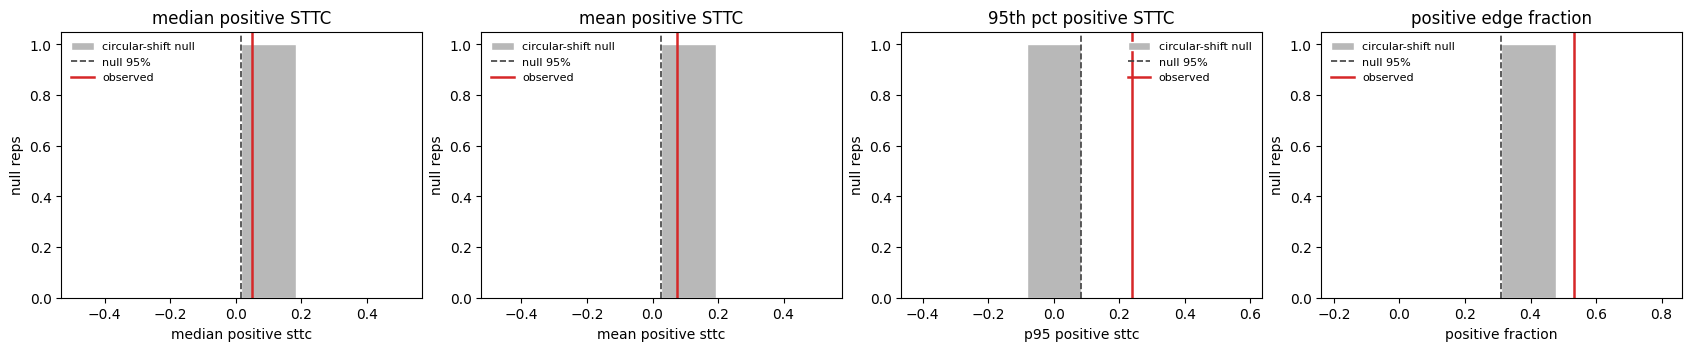

In [58]:
def observed_global_sttc_stats(result):
    adj = np.asarray(result["adjacency"], dtype=float)
    weights = adj[np.triu_indices_from(adj, k=1)] if adj.size else np.array([], dtype=float)
    positive = weights[np.isfinite(weights) & (weights > 0)]
    return {
        "mean_positive_sttc": float(np.mean(positive)) if positive.size else np.nan,
        "median_positive_sttc": float(np.median(positive)) if positive.size else np.nan,
        "p95_positive_sttc": float(np.quantile(positive, 0.95)) if positive.size else np.nan,
        "positive_fraction": float(np.mean(weights > 0)) if weights.size else np.nan,
    }


def draw_light_null_summary(result, null_df):
    if null_df is None or null_df.empty:
        print("No null results available. Set STTC_NULL_REPS > 0 and rerun the null cell.")
        return None
    observed = observed_global_sttc_stats(result)
    metrics = [
        ("median_positive_sttc", "median positive STTC"),
        ("mean_positive_sttc", "mean positive STTC"),
        ("p95_positive_sttc", "95th pct positive STTC"),
        ("positive_fraction", "positive edge fraction"),
    ]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.2 * len(metrics), 3.4), constrained_layout=True)
    for ax, (metric, label) in zip(axes, metrics):
        values = null_df[metric].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        if values.size:
            ax.hist(values, bins=min(30, max(6, values.size // 2)), color="0.72", edgecolor="white", label="circular-shift null")
            q95 = float(np.quantile(values, 0.95))
            ax.axvline(q95, color="0.25", ls="--", lw=1.2, label="null 95%")
        obs = observed.get(metric, np.nan)
        if np.isfinite(obs):
            ax.axvline(obs, color="tab:red", lw=1.8, label="observed")
        ax.set_title(label)
        ax.set_xlabel(metric.replace("_", " "))
        ax.set_ylabel("null reps")
        ax.legend(frameon=False, fontsize=8)
    return fig, axes

if sttc_results and not light_null_df.empty:
    example_sttc_result = get_example_sttc_result()
    draw_light_null_summary(example_sttc_result, light_null_df);
else:
    print("No null-controlled visual summary to show yet.")


## Null-Residual Example Network Panel

If `light_null_mean_adjacency` is available, this redraws the same example network panel on `observed STTC - mean circular-shift null STTC`, clipped at zero for positive residual structure.


In [ ]:
def null_corrected_adjacency(result, null_mean_adjacency):
    if null_mean_adjacency is None:
        return None
    observed = np.asarray(result["adjacency"], dtype=float)
    null_mean = np.asarray(null_mean_adjacency, dtype=float)
    if observed.shape != null_mean.shape:
        raise ValueError(
            f"Null adjacency shape {null_mean.shape} does not match observed {observed.shape}. "
            "Compute the null for this exact STTC result with draw_null_residual_network_for_result(result)."
        )
    corrected = observed - null_mean
    if not STTC_KEEP_NEGATIVE:
        corrected = np.maximum(corrected, 0.0)
    np.fill_diagonal(corrected, 0.0)
    return corrected


def matching_null_mean_for_result(result, n_reps=STTC_NULL_REPS):
    existing = globals().get("light_null_mean_adjacency")
    if existing is not None and np.asarray(existing).shape == np.asarray(result["adjacency"]).shape:
        return globals().get("light_null_df", pd.DataFrame()), existing
    return run_light_null_for_result(result, n_reps=n_reps, adjacency_reps=n_reps)


def exact_null_residual_distance_curve(result, corrected_adjacency):
    curve = binned_sttc_by_distance(
        result,
        bin_um=float(globals().get("STTC_DISTANCE_CURVE_BIN_UM", 100.0)),
        max_um=float(globals().get("STTC_DISTANCE_CURVE_MAX_UM", 3500.0)),
        adjacency=corrected_adjacency,
    )
    spec = result["item"]["spec"]
    if curve.empty:
        return curve
    return pd.DataFrame({
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": int(spec["div"]),
        "recording_id": spec["recording_id"],
        "distance_um": curve["distance_um"].astype(float),
        "n_pairs": curve["n_pairs"].astype(int),
        "median_positive_residual_sttc": curve["median_positive_sttc"].astype(float),
        "mean_positive_residual_sttc": curve["mean_sttc"].astype(float),
        "positive_residual_fraction": curve["positive_fraction"].astype(float),
        "curve_source": "exact_full_adjacency",
    })


def draw_null_residual_network_for_result(result, n_reps=STTC_NULL_REPS):
    null_df, null_mean = matching_null_mean_for_result(result, n_reps=n_reps)
    corrected = null_corrected_adjacency(result, null_mean)
    if corrected is None:
        raise ValueError("No matching null adjacency is available for the requested result.")
    fig_axes = draw_example_network(result, adjacency=corrected, title_prefix="Null-residual ")
    curve_df = exact_null_residual_distance_curve(result, corrected)
    return null_df, corrected, curve_df, fig_axes

example_null_residual_distance_df = pd.DataFrame()
if sttc_results and STTC_NULL_REPS > 0:
    example_sttc_result = get_example_sttc_result()
    light_null_df, corrected_adjacency, example_null_residual_distance_df, _ = draw_null_residual_network_for_result(example_sttc_result)
else:
    corrected_adjacency = None
    print("No null-residual adjacency available. Set STTC_NULL_REPS > 0 and rerun the null cells.")


## Aggregate Summaries

When `RUN_MODE` loads multiple wells or DIVs, these summaries compare recording-level network metrics without reloading raw spikes.

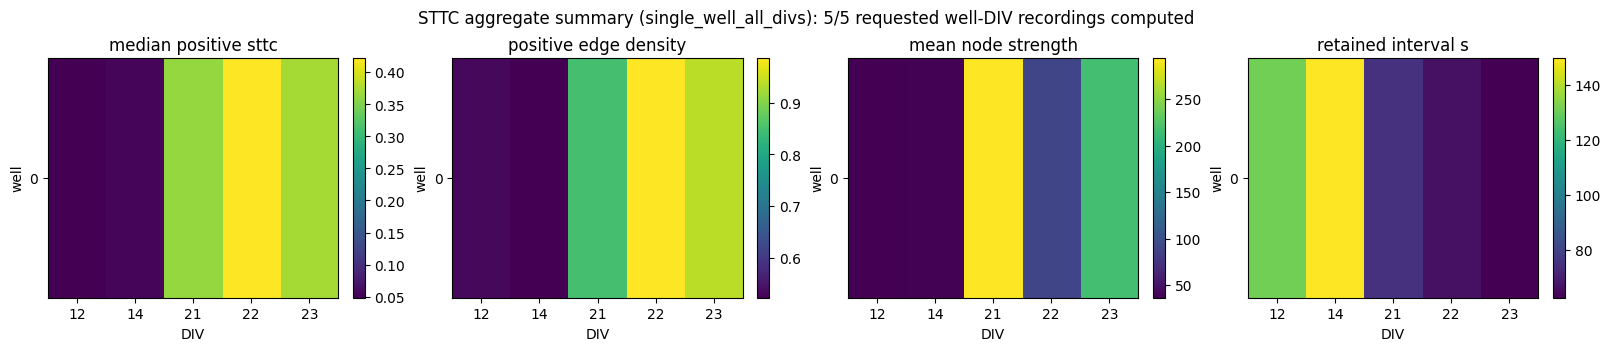

In [60]:
def draw_aggregate_summary(summary_df):
    metrics = ["median_positive_sttc", "positive_edge_density", "mean_node_strength", "retained_interval_s"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 3.4), constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]

    # Show exactly the requested matrix implied by RUN_ALL_WELLS/RUN_ALL_DIVS.
    wells = requested_wells()
    divs = requested_divs()

    for ax, metric in zip(axes, metrics):
        if summary_df.empty:
            pivot = pd.DataFrame(index=wells, columns=divs, dtype=float)
        else:
            pivot = summary_df.pivot_table(index="well", columns="div", values=metric, aggfunc="median")
            pivot = pivot.reindex(index=wells, columns=divs)
        values = pivot.to_numpy(dtype=float)
        masked = np.ma.masked_invalid(values)
        cmap = plt.get_cmap("viridis").copy()
        cmap.set_bad("0.90")
        im = ax.imshow(masked, aspect="auto", cmap=cmap)
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("DIV")
        ax.set_ylabel("well")
        ax.set_xticks(np.arange(len(divs)))
        ax.set_xticklabels([str(c) for c in divs])
        ax.set_yticks(np.arange(len(wells)))
        ax.set_yticklabels([str(i) for i in wells])
        for yi in range(len(wells)):
            for xi in range(len(divs)):
                if not np.isfinite(values[yi, xi]):
                    ax.text(xi, yi, "missing", ha="center", va="center", color="0.45", fontsize=7)
        fig.colorbar(im, ax=ax)
    computed_pairs = set()
    if not summary_df.empty:
        computed_pairs = set(zip(summary_df["well"].astype(int), summary_df["div"].astype(int)))
    requested_pairs = {(int(w), int(d)) for w in wells for d in divs}
    missing_n = len(requested_pairs - computed_pairs)
    fig.suptitle(
        f"STTC aggregate summary ({RUN_MODE}): {len(computed_pairs & requested_pairs)}/{len(requested_pairs)} requested well-DIV recordings computed"
        + (f"; {missing_n} missing/skipped" if missing_n else "")
    )
    return fig, axes

draw_aggregate_summary(sttc_summary_df);


In [61]:
# Shared helpers for all null-residual panels. Keep this cell before the distance and matrix summaries.
def null_residual_cache_path_for_result(result, n_reps, n_pairs=STTC_NULL_PAIR_SAMPLE_PER_RECORDING):
    spec = result["item"]["spec"]
    max_label = "all" if STTC_MAX_ELECTRODES is None else str(int(STTC_MAX_ELECTRODES))
    dt_label = f"{float(STTC_DT_MS):g}".replace(".", "p")
    sample_label = "allpairs" if n_pairs is None else f"pairs{int(n_pairs)}"
    strat_label = "stratdist" if STTC_NULL_PAIR_STRATIFY_BY_DISTANCE else "random"
    clip_label = "posclip" if not STTC_KEEP_NEGATIVE else "signed"
    return OUTPUT_DIR / (
        f"null_residual_sampled_v2_{spec['recording_id']}_{STTC_ACTIVITY_SCOPE}_"
        f"dt{dt_label}ms_max{max_label}_{sample_label}_{strat_label}_"
        f"pairbin{int(STTC_NULL_PAIR_DISTANCE_BIN_UM)}um_{clip_label}_reps{int(n_reps)}_seed{int(STTC_RANDOM_SEED)}.csv"
    )


def sample_pair_indices_for_null(result, n_pairs=STTC_NULL_PAIR_SAMPLE_PER_RECORDING):
    adj = np.asarray(result["adjacency"], dtype=float)
    n = adj.shape[0]
    i_all, j_all = np.triu_indices(n, k=1)
    if n_pairs is None or int(n_pairs) >= i_all.size:
        return i_all, j_all

    coords = np.asarray(result["coords_um"], dtype=float)
    distances = np.sqrt(np.sum((coords[i_all] - coords[j_all]) ** 2, axis=1))
    seed = STTC_RANDOM_SEED + 15485863 * int(result["item"]["spec"]["well"]) + 32452843 * int(result["item"]["spec"]["div"])
    rng = np.random.default_rng(seed)
    n_pairs = int(n_pairs)

    if not STTC_NULL_PAIR_STRATIFY_BY_DISTANCE:
        pick = rng.choice(i_all.size, size=n_pairs, replace=False)
        return i_all[pick], j_all[pick]

    max_distance = float(np.nanmax(distances)) if distances.size else 0.0
    edges = np.arange(0.0, max_distance + float(STTC_NULL_PAIR_DISTANCE_BIN_UM), float(STTC_NULL_PAIR_DISTANCE_BIN_UM))
    if edges.size < 2:
        pick = rng.choice(i_all.size, size=n_pairs, replace=False)
        return i_all[pick], j_all[pick]
    bin_ids = np.digitize(distances, edges) - 1
    valid_bins = [b for b in np.unique(bin_ids) if np.any(bin_ids == b)]
    per_bin = max(1, int(np.ceil(n_pairs / max(1, len(valid_bins)))))
    picks = []
    for b in valid_bins:
        candidates = np.flatnonzero(bin_ids == b)
        take = min(per_bin, candidates.size)
        picks.append(rng.choice(candidates, size=take, replace=False))
    pick = np.concatenate(picks) if picks else np.array([], dtype=int)
    if pick.size > n_pairs:
        pick = rng.choice(pick, size=n_pairs, replace=False)
    elif pick.size < n_pairs:
        remaining = np.setdiff1d(np.arange(i_all.size), pick, assume_unique=False)
        if remaining.size:
            extra = rng.choice(remaining, size=min(n_pairs - pick.size, remaining.size), replace=False)
            pick = np.concatenate([pick, extra])
    return i_all[pick], j_all[pick]


def sttc_pair_value_from_precomputed(a, b, duration_s, dt_s, ta, tb):
    pa = sttc_spike_proportion(a, b, dt_s)
    pb = sttc_spike_proportion(b, a, dt_s)
    denom_a = 1.0 - pa * tb
    denom_b = 1.0 - pb * ta
    term_a = 0.0 if np.isclose(denom_a, 0.0) else (pa - tb) / denom_a
    term_b = 0.0 if np.isclose(denom_b, 0.0) else (pb - ta) / denom_b
    value = 0.5 * (term_a + term_b)
    return max(0.0, value) if not STTC_KEEP_NEGATIVE else value


def compute_sampled_pair_sttc(spikes_by_electrode, electrodes, pair_i, pair_j, duration_s, dt_s):
    electrodes = np.asarray(electrodes, dtype=int)
    used = np.unique(np.concatenate([np.asarray(pair_i, dtype=int), np.asarray(pair_j, dtype=int)]))
    tiling = {
        int(e): sttc_tiling_proportion(spikes_by_electrode[int(e)], duration_s, dt_s)
        for e in electrodes[used]
    }
    out = np.empty(pair_i.size, dtype=np.float32)
    for idx, (i, j) in enumerate(zip(pair_i, pair_j)):
        ei = int(electrodes[int(i)])
        ej = int(electrodes[int(j)])
        out[idx] = sttc_pair_value_from_precomputed(
            spikes_by_electrode[ei],
            spikes_by_electrode[ej],
            duration_s,
            dt_s,
            tiling[ei],
            tiling[ej],
        )
    return out


def summarize_positive_residual_values(values):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    positive = finite[finite > 0]
    return {
        "median_positive_residual_sttc": float(np.median(positive)) if positive.size else np.nan,
        "mean_positive_residual_sttc": float(np.mean(positive)) if positive.size else np.nan,
        "positive_residual_fraction": float(positive.size / finite.size) if finite.size else np.nan,
        "n_positive_residual_edges": int(positive.size),
        "n_sampled_pairs": int(finite.size),
    }


## Null-Residual Positive STTC Over Distance

This is the distance-resolved view analogous to the activity-distance panel: one curve per well-DIV recording. Curves show binned sampled-pair residual STTC after circular-shift null correction, with replicate intervals across null shifts.


In [ ]:
# Defaults make this section safe to rerun after older config cells.
STTC_DISTANCE_CURVE_BIN_UM = globals().get("STTC_DISTANCE_CURVE_BIN_UM", 100.0)
STTC_DISTANCE_CURVE_MAX_UM = globals().get("STTC_DISTANCE_CURVE_MAX_UM", 3500.0)

def null_residual_distance_cache_path_for_result(result, n_reps=STTC_NULL_REPS):
    spec = result["item"]["spec"]
    max_label = "all" if STTC_MAX_ELECTRODES is None else str(int(STTC_MAX_ELECTRODES))
    dt_label = f"{float(STTC_DT_MS):g}".replace(".", "p")
    sample_label = "allpairs" if STTC_NULL_PAIR_SAMPLE_PER_RECORDING is None else f"pairs{int(STTC_NULL_PAIR_SAMPLE_PER_RECORDING)}"
    strat_label = "stratdist" if STTC_NULL_PAIR_STRATIFY_BY_DISTANCE else "random"
    clip_label = "posclip" if not STTC_KEEP_NEGATIVE else "signed"
    return OUTPUT_DIR / (
        f"null_residual_distance_v2_{spec['recording_id']}_{STTC_ACTIVITY_SCOPE}_"
        f"dt{dt_label}ms_max{max_label}_{sample_label}_{strat_label}_"
        f"pairbin{int(STTC_NULL_PAIR_DISTANCE_BIN_UM)}um_curvebin{int(STTC_DISTANCE_CURVE_BIN_UM)}um_"
        f"curveMax{int(STTC_DISTANCE_CURVE_MAX_UM)}um_{clip_label}_reps{int(n_reps)}_seed{int(STTC_RANDOM_SEED)}.csv"
    )


def compute_null_residual_distance_for_result(result, n_reps=STTC_NULL_REPS):
    cache_path = null_residual_distance_cache_path_for_result(result, n_reps=n_reps)
    if cache_path.exists() and not STTC_NULL_RESIDUAL_FORCE_RECOMPUTE:
        return pd.read_csv(cache_path)

    item = result["item"]
    observed = np.asarray(result["adjacency"], dtype=float)
    coords = np.asarray(result["coords_um"], dtype=float)
    pair_i, pair_j = sample_pair_indices_for_null(result)
    observed_pairs = observed[pair_i, pair_j]
    distances = np.sqrt(np.sum((coords[pair_i] - coords[pair_j]) ** 2, axis=1))
    bins = np.arange(0.0, float(STTC_DISTANCE_CURVE_MAX_UM) + float(STTC_DISTANCE_CURVE_BIN_UM), float(STTC_DISTANCE_CURVE_BIN_UM))
    centers = 0.5 * (bins[:-1] + bins[1:])
    bin_ids = np.digitize(distances, bins) - 1
    supported = (bin_ids >= 0) & (bin_ids < centers.size)

    intervals = item["selected_intervals"][["start_time_s", "end_time_s"]].to_numpy(dtype=float)
    spikes_by_electrode, duration_s = spike_times_by_electrode_in_intervals(item["recording"], result["electrodes"], intervals)
    rng = np.random.default_rng(STTC_RANDOM_SEED + 3571 * int(item["spec"]["well"]) + 10007 * int(item["spec"]["div"]))
    dt_s = float(STTC_DT_MS) / 1000.0
    rows = []
    for rep in range(int(n_reps)):
        shifted = circular_shift_spikes(spikes_by_electrode, duration_s, rng)
        null_pairs = compute_sampled_pair_sttc(shifted, result["electrodes"], pair_i, pair_j, duration_s, dt_s)
        residual = observed_pairs - null_pairs
        if not STTC_KEEP_NEGATIVE:
            residual = np.maximum(residual, 0.0)
        for bin_idx, center in enumerate(centers):
            mask = supported & (bin_ids == bin_idx)
            values = residual[mask]
            positive = values[np.isfinite(values) & (values > 0)]
            rows.append({
                "rep": rep,
                "dataset": item["spec"]["dataset"],
                "well": int(item["spec"]["well"]),
                "div": int(item["spec"]["div"]),
                "recording_id": item["spec"]["recording_id"],
                "distance_um": float(center),
                "n_pairs": int(np.sum(mask)),
                "median_positive_residual_sttc": float(np.median(positive)) if positive.size else np.nan,
                "mean_positive_residual_sttc": float(np.mean(positive)) if positive.size else np.nan,
                "positive_residual_fraction": float(positive.size / values.size) if values.size else np.nan,
            })
    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


def build_null_residual_distance_summary(results, n_reps=STTC_NULL_REPS):
    parts = [compute_null_residual_distance_for_result(result, n_reps=n_reps) for result in results]
    reps_df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    if reps_df.empty:
        return reps_df, pd.DataFrame()
    rows = []
    for (well, div, distance_um), group in reps_df.groupby(["well", "div", "distance_um"]):
        values = group["median_positive_residual_sttc"].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        n_pairs = group["n_pairs"].to_numpy(dtype=float)
        rows.append({
            "well": int(well),
            "div": int(div),
            "distance_um": float(distance_um),
            "median_positive_residual_sttc": float(np.median(values)) if values.size else np.nan,
            "ci_low": float(np.quantile(values, 0.025)) if values.size else np.nan,
            "ci_high": float(np.quantile(values, 0.975)) if values.size else np.nan,
            "mean_n_pairs": float(np.nanmean(n_pairs)) if n_pairs.size else np.nan,
            "n_null_reps": int(values.size),
        })
    return reps_df, pd.DataFrame(rows)


def summarize_distance_average_curve(reps_df, *, well=None, div=None):
    if reps_df is None or reps_df.empty:
        return pd.DataFrame()
    group = reps_df.copy()
    if well is not None:
        group = group[group["well"] == int(well)]
    if div is not None:
        group = group[group["div"] == int(div)]
    if group.empty:
        return pd.DataFrame()
    rep_distance = (
        group.groupby(["rep", "distance_um"], as_index=False)["median_positive_residual_sttc"]
        .mean()
        .dropna(subset=["median_positive_residual_sttc"])
    )
    rows = []
    for distance_um, distance_group in rep_distance.groupby("distance_um"):
        values = distance_group["median_positive_residual_sttc"].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        rows.append({
            "distance_um": float(distance_um),
            "mean_residual_sttc": float(np.median(values)) if values.size else np.nan,
            "ci_low": float(np.quantile(values, 0.025)) if values.size else np.nan,
            "ci_high": float(np.quantile(values, 0.975)) if values.size else np.nan,
            "n_reps": int(values.size),
        })
    return pd.DataFrame(rows).sort_values("distance_um")


def draw_curve_with_ci(ax, curve_df, *, color="tab:blue", title=None):
    if curve_df is None or curve_df.empty:
        ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", color="0.55")
        return
    x = curve_df["distance_um"].to_numpy(dtype=float)
    y = curve_df["mean_residual_sttc"].to_numpy(dtype=float)
    lo = curve_df["ci_low"].to_numpy(dtype=float)
    hi = curve_df["ci_high"].to_numpy(dtype=float)
    ax.fill_between(x, lo, hi, color=color, alpha=0.14, lw=0)
    ax.plot(x, y, marker="o", ms=2.2, lw=1.1, color=color)
    if title:
        ax.set_title(title)


def draw_null_residual_distance_grid(summary_df, reps_df=None):
    wells = requested_wells()
    divs = requested_divs()
    fig = plt.figure(
        figsize=(2.45 * len(divs) + 2.6, 1.65 * len(wells) + 2.2),
        constrained_layout=True,
    )
    gs = fig.add_gridspec(
        len(wells) + 1,
        len(divs) + 1,
        width_ratios=[1.0] * len(divs) + [1.05],
        height_ratios=[1.0] * len(wells) + [1.0],
    )
    axes = np.empty((len(wells), len(divs)), dtype=object)
    row_axes = []
    col_axes = []
    finite_values = summary_df["median_positive_residual_sttc"].to_numpy(dtype=float) if not summary_df.empty else np.array([])
    finite_values = finite_values[np.isfinite(finite_values)]
    if reps_df is not None and not reps_df.empty:
        avg_values = reps_df["median_positive_residual_sttc"].to_numpy(dtype=float)
        avg_values = avg_values[np.isfinite(avg_values)]
        finite_values = np.r_[finite_values, avg_values]
    y_max = max(0.01, float(np.nanquantile(finite_values, 0.98)) * 1.15) if finite_values.size else 0.1

    for row_idx, well in enumerate(wells):
        for col_idx, div in enumerate(divs):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            axes[row_idx, col_idx] = ax
            group = summary_df[(summary_df["well"] == int(well)) & (summary_df["div"] == int(div))].sort_values("distance_um")
            if group.empty:
                ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", color="0.55")
            else:
                x = group["distance_um"].to_numpy(dtype=float)
                y = group["median_positive_residual_sttc"].to_numpy(dtype=float)
                lo = group["ci_low"].to_numpy(dtype=float)
                hi = group["ci_high"].to_numpy(dtype=float)
                ax.fill_between(x, lo, hi, color="tab:blue", alpha=0.14, lw=0)
                ax.plot(x, y, marker="o", ms=2.2, lw=1.0, color="tab:blue")
                valid_bins = int(np.sum(np.isfinite(y)))
                ax.text(0.98, 0.90, f"n={valid_bins}", transform=ax.transAxes, ha="right", va="top", fontsize=7, color="0.35")
            ax.axhline(0.0, color="0.65", lw=0.8)
            ax.set_ylim(0.0, y_max)
            if row_idx == 0:
                ax.set_title(f"DIV {div}")
            if col_idx == 0:
                ax.set_ylabel(f"well {well}\nresidual STTC")
            else:
                ax.tick_params(labelleft=False)
            if row_idx == len(wells) - 1:
                ax.set_xlabel("distance (um)")
            else:
                ax.tick_params(labelbottom=False)

        ax_row = fig.add_subplot(gs[row_idx, len(divs)])
        row_axes.append(ax_row)
        draw_curve_with_ci(ax_row, summarize_distance_average_curve(reps_df, well=well), color="tab:red", title="well avg" if row_idx == 0 else None)
        ax_row.axhline(0.0, color="0.65", lw=0.8)
        ax_row.set_ylim(0.0, y_max)
        ax_row.tick_params(labelleft=False)
        if row_idx == len(wells) - 1:
            ax_row.set_xlabel("distance (um)")
        else:
            ax_row.tick_params(labelbottom=False)

    for col_idx, div in enumerate(divs):
        ax_col = fig.add_subplot(gs[len(wells), col_idx])
        col_axes.append(ax_col)
        draw_curve_with_ci(ax_col, summarize_distance_average_curve(reps_df, div=div), color="tab:red", title="DIV avg")
        ax_col.axhline(0.0, color="0.65", lw=0.8)
        ax_col.set_ylim(0.0, y_max)
        ax_col.set_xlabel("distance (um)")
        if col_idx == 0:
            ax_col.set_ylabel("DIV avg\nresidual STTC")
        else:
            ax_col.tick_params(labelleft=False)

    ax_overall = fig.add_subplot(gs[len(wells), len(divs)])
    draw_curve_with_ci(ax_overall, summarize_distance_average_curve(reps_df), color="tab:red", title="overall avg")
    ax_overall.axhline(0.0, color="0.65", lw=0.8)
    ax_overall.set_ylim(0.0, y_max)
    ax_overall.tick_params(labelleft=False)
    ax_overall.set_xlabel("distance (um)")
    fig.suptitle("Null-residual positive STTC by well and DIV")
    return fig, {"cells": axes, "row_avg": row_axes, "col_avg": col_axes, "overall": ax_overall}



def replace_distance_curve_with_exact_example(summary_df, reps_df):
    """Make the grid cell for the configured example exactly reuse the example-panel curve."""
    exact = globals().get("example_null_residual_distance_df", pd.DataFrame())
    if exact is None or exact.empty:
        print("No exact example distance curve is available; grid uses sampled-pair residual curves only.")
        return summary_df, reps_df
    required = {"well", "div", "distance_um", "median_positive_residual_sttc"}
    missing = required.difference(exact.columns)
    if missing:
        raise ValueError(f"Exact example distance curve is missing columns: {sorted(missing)}")

    exact = exact.copy()
    well = int(exact["well"].iloc[0])
    div = int(exact["div"].iloc[0])
    exact_summary = pd.DataFrame({
        "well": well,
        "div": div,
        "distance_um": exact["distance_um"].astype(float),
        "median_positive_residual_sttc": exact["median_positive_residual_sttc"].astype(float),
        "ci_low": exact["median_positive_residual_sttc"].astype(float),
        "ci_high": exact["median_positive_residual_sttc"].astype(float),
        "mean_n_pairs": exact.get("n_pairs", pd.Series(np.nan, index=exact.index)).astype(float),
        "n_null_reps": int(globals().get("STTC_NULL_REPS", 0)),
        "curve_source": "exact_full_adjacency_example",
    })
    exact_reps = pd.DataFrame({
        "rep": 0,
        "dataset": exact.get("dataset", pd.Series("", index=exact.index)),
        "well": well,
        "div": div,
        "recording_id": exact.get("recording_id", pd.Series("", index=exact.index)),
        "distance_um": exact["distance_um"].astype(float),
        "n_pairs": exact.get("n_pairs", pd.Series(np.nan, index=exact.index)).astype(float),
        "median_positive_residual_sttc": exact["median_positive_residual_sttc"].astype(float),
        "mean_positive_residual_sttc": exact.get("mean_positive_residual_sttc", exact["median_positive_residual_sttc"]).astype(float),
        "positive_residual_fraction": exact.get("positive_residual_fraction", pd.Series(np.nan, index=exact.index)).astype(float),
        "curve_source": "exact_full_adjacency_example",
    })

    if summary_df is not None and not summary_df.empty:
        keep = ~((summary_df["well"] == well) & (summary_df["div"] == div))
        summary_df = pd.concat([summary_df.loc[keep], exact_summary], ignore_index=True)
    else:
        summary_df = exact_summary
    if reps_df is not None and not reps_df.empty:
        keep = ~((reps_df["well"] == well) & (reps_df["div"] == div))
        reps_df = pd.concat([reps_df.loc[keep], exact_reps], ignore_index=True)
    else:
        reps_df = exact_reps
    print(f"Inserted exact example-panel residual curve into grid: well {well}, DIV {div}.")
    return summary_df, reps_df

null_residual_distance_reps_df, null_residual_distance_summary_df = build_null_residual_distance_summary(sttc_results)
null_residual_distance_summary_df, null_residual_distance_reps_df = replace_distance_curve_with_exact_example(
    null_residual_distance_summary_df,
    null_residual_distance_reps_df,
)
if not null_residual_distance_summary_df.empty:
    draw_null_residual_distance_grid(null_residual_distance_summary_df, null_residual_distance_reps_df);
else:
    print("No null-residual distance summary available. Compute STTC results first.")


## All-Well/All-DIV Null-Residual Positive STTC Panel

This panel summarizes null-residual positive STTC for every computed well-DIV recording. Each cell uses `observed adjacency - circular-shift null adjacency`, clipped at zero when `STTC_KEEP_NEGATIVE=False`, then summarizes the median positive residual edge weight. The margins show row-wise well averages and column-wise DIV averages with replicate-based 95% intervals.


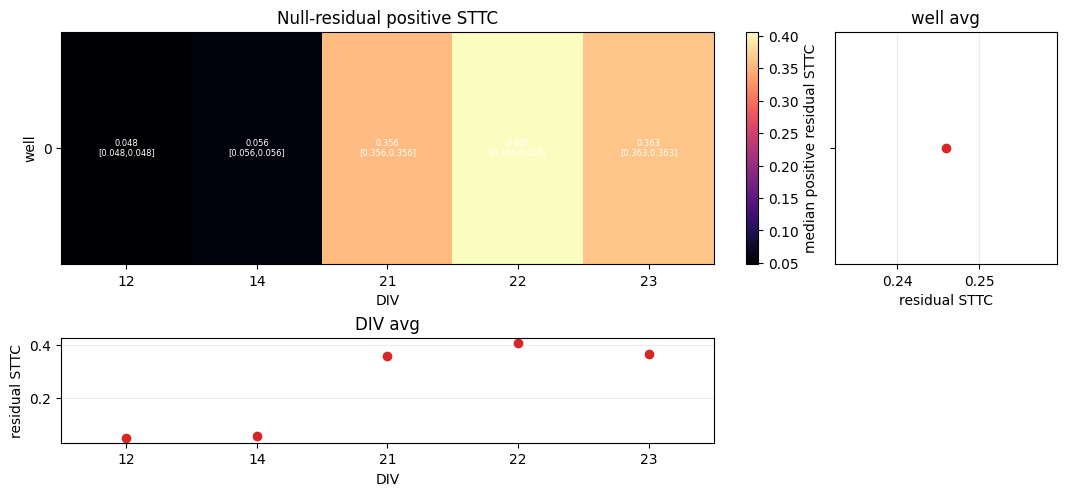

In [63]:
# Uses shared null-residual helpers defined above.
# Do not redefine cache-path or pair-sampling helpers here; otherwise old caches can be reused.

def compute_null_residual_summary_for_result(result, n_reps=STTC_NULL_REPS):
    cache_path = null_residual_cache_path_for_result(result, n_reps)
    if cache_path.exists() and not STTC_NULL_RESIDUAL_FORCE_RECOMPUTE:
        return pd.read_csv(cache_path)

    item = result["item"]
    observed = np.asarray(result["adjacency"], dtype=float)
    pair_i, pair_j = sample_pair_indices_for_null(result)
    observed_pairs = observed[pair_i, pair_j]
    intervals = item["selected_intervals"][["start_time_s", "end_time_s"]].to_numpy(dtype=float)
    spikes_by_electrode, duration_s = spike_times_by_electrode_in_intervals(item["recording"], result["electrodes"], intervals)
    rng = np.random.default_rng(STTC_RANDOM_SEED + 7919 * int(item["spec"]["well"]) + 104729 * int(item["spec"]["div"]))
    dt_s = float(STTC_DT_MS) / 1000.0
    rows = []
    for rep in range(int(n_reps)):
        shifted = circular_shift_spikes(spikes_by_electrode, duration_s, rng)
        null_pairs = compute_sampled_pair_sttc(shifted, result["electrodes"], pair_i, pair_j, duration_s, dt_s)
        residual = observed_pairs - null_pairs
        if not STTC_KEEP_NEGATIVE:
            residual = np.maximum(residual, 0.0)
        row = summarize_positive_residual_values(residual)
        row.update({
            "rep": rep,
            "dataset": item["spec"]["dataset"],
            "well": int(item["spec"]["well"]),
            "div": int(item["spec"]["div"]),
            "recording_id": item["spec"]["recording_id"],
            "n_electrodes": int(observed.shape[0]),
            "pair_sample_method": "distance_stratified" if STTC_NULL_PAIR_STRATIFY_BY_DISTANCE else "random",
        })
        rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


def build_null_residual_grid_summary(results, n_reps=STTC_NULL_REPS):
    parts = []
    for result in results:
        parts.append(compute_null_residual_summary_for_result(result, n_reps=n_reps))
    reps_df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    if reps_df.empty:
        return reps_df, pd.DataFrame()
    cell_rows = []
    for (well, div), group in reps_df.groupby(["well", "div"]):
        values = group["median_positive_residual_sttc"].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        cell_rows.append({
            "well": int(well),
            "div": int(div),
            "median_positive_residual_sttc": float(np.median(values)) if values.size else np.nan,
            "ci_low": float(np.quantile(values, 0.025)) if values.size else np.nan,
            "ci_high": float(np.quantile(values, 0.975)) if values.size else np.nan,
            "n_null_reps": int(values.size),
        })
    return reps_df, pd.DataFrame(cell_rows)


def _mean_ci_from_rep_table(reps_df, group_col, values):
    rows = []
    for key, group in reps_df.groupby(group_col):
        rep_means = group.groupby("rep")[values].mean().to_numpy(dtype=float)
        rep_means = rep_means[np.isfinite(rep_means)]
        rows.append({
            group_col: int(key),
            "mean": float(np.median(rep_means)) if rep_means.size else np.nan,
            "ci_low": float(np.quantile(rep_means, 0.025)) if rep_means.size else np.nan,
            "ci_high": float(np.quantile(rep_means, 0.975)) if rep_means.size else np.nan,
        })
    return pd.DataFrame(rows)

def draw_null_residual_well_div_panel(cell_df, reps_df):
    wells = requested_wells()
    divs = requested_divs()
    metric = "median_positive_residual_sttc"
    pivot = cell_df.pivot_table(index="well", columns="div", values=metric, aggfunc="median").reindex(index=wells, columns=divs)
    low = cell_df.pivot_table(index="well", columns="div", values="ci_low", aggfunc="median").reindex(index=wells, columns=divs)
    high = cell_df.pivot_table(index="well", columns="div", values="ci_high", aggfunc="median").reindex(index=wells, columns=divs)
    values = pivot.to_numpy(dtype=float)

    row_summary = _mean_ci_from_rep_table(reps_df[reps_df["well"].isin(wells) & reps_df["div"].isin(divs)], "well", metric)
    col_summary = _mean_ci_from_rep_table(reps_df[reps_df["well"].isin(wells) & reps_df["div"].isin(divs)], "div", metric)

    fig = plt.figure(figsize=(1.15 * len(divs) + 4.8, 0.65 * len(wells) + 4.2), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, width_ratios=[max(3, len(divs)), 1.7], height_ratios=[max(3, len(wells)), 1.35])
    ax = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[0, 1], sharey=ax)
    ax_bottom = fig.add_subplot(gs[1, 0], sharex=ax)
    ax_empty = fig.add_subplot(gs[1, 1])
    ax_empty.axis("off")

    masked = np.ma.masked_invalid(values)
    cmap = plt.get_cmap("magma").copy()
    cmap.set_bad("0.90")
    im = ax.imshow(masked, aspect="auto", cmap=cmap)
    ax.set_title("Null-residual positive STTC")
    ax.set_xlabel("DIV")
    ax.set_ylabel("well")
    ax.set_xticks(np.arange(len(divs)))
    ax.set_xticklabels([str(d) for d in divs])
    ax.set_yticks(np.arange(len(wells)))
    ax.set_yticklabels([str(w) for w in wells])
    for yi, well in enumerate(wells):
        for xi, div in enumerate(divs):
            value = pivot.loc[well, div]
            if np.isfinite(value):
                lo = low.loc[well, div]
                hi = high.loc[well, div]
                ax.text(xi, yi, f"{value:.3f}\n[{lo:.3f},{hi:.3f}]", ha="center", va="center", fontsize=6, color="white")
            else:
                ax.text(xi, yi, "missing", ha="center", va="center", fontsize=7, color="0.45")
    fig.colorbar(im, ax=ax, label="median positive residual STTC")

    row_summary = row_summary.set_index("well").reindex(wells)
    y = np.arange(len(wells))
    row_mean = row_summary["mean"].to_numpy(dtype=float)
    row_xerr = np.vstack([
        row_mean - row_summary["ci_low"].to_numpy(dtype=float),
        row_summary["ci_high"].to_numpy(dtype=float) - row_mean,
    ])
    ax_right.errorbar(row_mean, y, xerr=row_xerr, fmt="o", color="tab:red", ecolor="0.35", capsize=2)
    ax_right.set_title("well avg")
    ax_right.set_xlabel("residual STTC")
    ax_right.tick_params(labelleft=False)
    ax_right.grid(axis="x", alpha=0.25)

    col_summary = col_summary.set_index("div").reindex(divs)
    x = np.arange(len(divs))
    col_mean = col_summary["mean"].to_numpy(dtype=float)
    col_yerr = np.vstack([
        col_mean - col_summary["ci_low"].to_numpy(dtype=float),
        col_summary["ci_high"].to_numpy(dtype=float) - col_mean,
    ])
    ax_bottom.errorbar(x, col_mean, yerr=col_yerr, fmt="o", color="tab:red", ecolor="0.35", capsize=2)
    ax_bottom.set_title("DIV avg")
    ax_bottom.set_ylabel("residual STTC")
    ax_bottom.set_xlabel("DIV")
    ax_bottom.grid(axis="y", alpha=0.25)
    return fig, (ax, ax_right, ax_bottom)

null_residual_reps_df, null_residual_cell_df = build_null_residual_grid_summary(sttc_results)
if not null_residual_cell_df.empty:
    draw_null_residual_well_div_panel(null_residual_cell_df, null_residual_reps_df);
else:
    print("No null-residual STTC grid available. Compute STTC results first.")


In [64]:
# Save thresholded edge tables and distance summaries for downstream graph analysis.
edge_output_rows = []
distance_output_rows = []
for result in sttc_results:
    spec = result["item"]["spec"]
    for fraction, edge_df in result["edge_tables"].items():
        if edge_df is None or edge_df.empty:
            continue
        edge_df = edge_df.copy()
        edge_df.insert(0, "top_fraction", fraction)
        edge_df.insert(0, "recording_id", spec["recording_id"])
        edge_df.insert(0, "div", spec["div"])
        edge_df.insert(0, "well", spec["well"])
        edge_output_rows.append(edge_df)
    distance_df = binned_sttc_by_distance(result)
    if not distance_df.empty:
        distance_df.insert(0, "recording_id", spec["recording_id"])
        distance_df.insert(0, "div", spec["div"])
        distance_df.insert(0, "well", spec["well"])
        distance_output_rows.append(distance_df)

edge_summary_df = pd.concat(edge_output_rows, ignore_index=True) if edge_output_rows else pd.DataFrame()
distance_summary_df = pd.concat(distance_output_rows, ignore_index=True) if distance_output_rows else pd.DataFrame()

edge_summary_df.to_csv(OUTPUT_DIR / "sttc_thresholded_edges.csv", index=False)
distance_summary_df.to_csv(OUTPUT_DIR / "sttc_distance_summary.csv", index=False)
interval_summary.to_csv(OUTPUT_DIR / "sttc_interval_summary.csv", index=False)
recording_summary.to_csv(OUTPUT_DIR / "sttc_activity_state_summary.csv", index=False)

print(f"Wrote outputs to {OUTPUT_DIR}")
print(f"recordings: {len(sttc_summary_df)}, edge rows: {len(edge_summary_df)}, distance rows: {len(distance_summary_df)}")

Wrote outputs to /Users/danielrebbin/Documents/GitHub/ephax/outputs/sttc_networks
recordings: 5, edge rows: 169600, distance rows: 175
